Load and Clean Data

In [44]:
import pandas as pd


df = pd.read_csv("cleaned_reviews.csv")
print(df.columns)

##df = pd.read_csv("final_bank_review_analysis.csv")
# Clean column names
df.columns = df.columns.str.strip().str.lower()

# Rename for convenience
df.rename(columns={
    'review text': 'review_text',
    'rating (1–5)': 'rating',
    'review date': 'review_date',
    'bank / app name': 'bank_name'
}, inplace=True)
print(df.columns.tolist())

# Convert date
df['review_date'] = pd.to_datetime(df['review_date'], errors='coerce')



Index(['review text', 'rating (1–5)', 'review date', 'bank / app name',
       'source'],
      dtype='str')
['review_text', 'rating', 'review_date', 'bank_name', 'source']


Sentiment Distribution by Bank (Stacked Bar)

In [45]:
from textblob import TextBlob
import pandas as pd

def get_sentiment(text):
    polarity = TextBlob(str(text)).sentiment.polarity

    if polarity > 0:
        return "positive"
    elif polarity < 0:
        return "negative"
    else:
        return "neutral"

df['sentiment_label'] = df['review_text'].apply(get_sentiment)

# Simple theme extraction
def identify_theme(text):
    text = str(text).lower()

    if 'login' in text:
        return 'Login Issues'
    elif 'transfer' in text:
        return 'Money Transfer'
    elif 'slow' in text:
        return 'Performance'
    else:
        return 'General'

df['identified_theme'] = df['review_text'].apply(identify_theme)


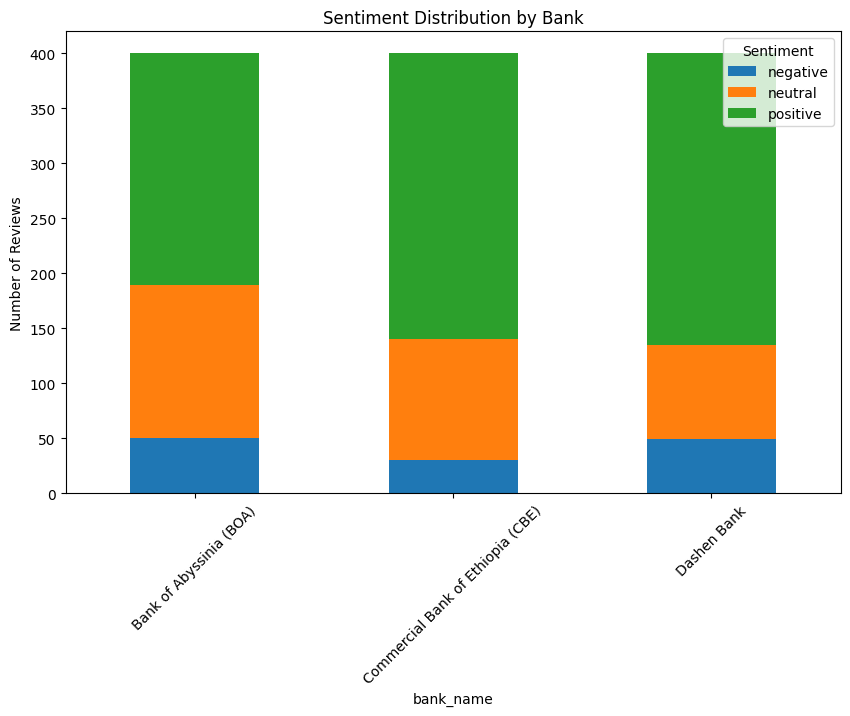

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt
sentiment_counts = df.groupby(['bank_name', 'sentiment_label']).size().unstack()

sentiment_counts.plot(kind='bar', stacked=True, figsize=(10,6))

plt.title("Sentiment Distribution by Bank")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)
plt.legend(title="Sentiment")
plt.show()

Rating Distribution (Boxplot)

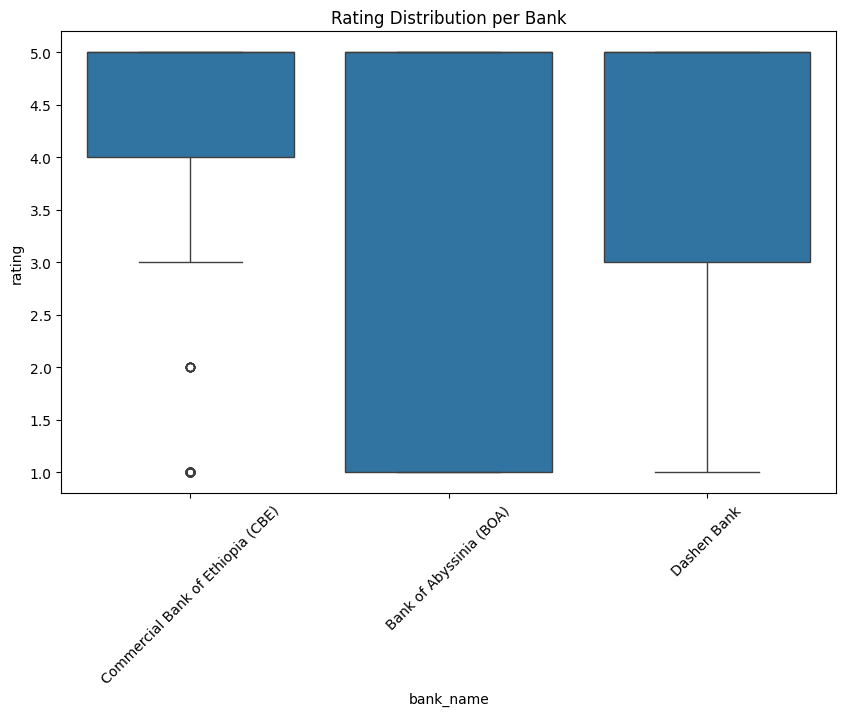

In [47]:
plt.figure(figsize=(10,6))

sns.boxplot(data=df, x='bank_name', y='rating')

plt.title("Rating Distribution per Bank")
plt.xticks(rotation=45)
plt.show()

Rating Histogram per Bank

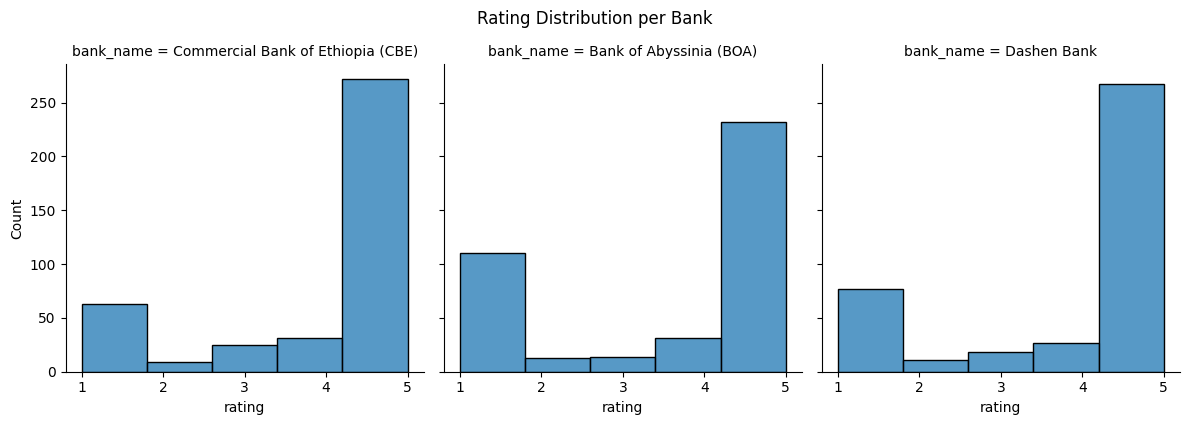

In [48]:
g = sns.FacetGrid(df, col="bank_name", height=4, col_wrap=3)
g.map(sns.histplot, "rating", bins=5)

g.fig.suptitle("Rating Distribution per Bank", y=1.05)
plt.show()

Top Themes per Bank

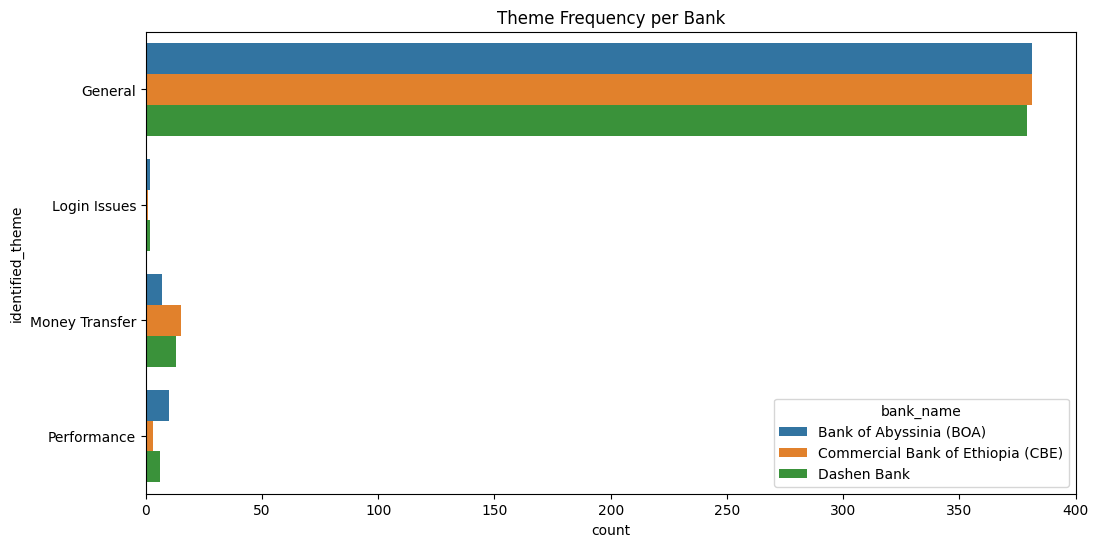

In [49]:
theme_counts = df.groupby(['bank_name', 'identified_theme']).size().reset_index(name='count')

plt.figure(figsize=(12,6))

sns.barplot(
    data=theme_counts,
    x='count',
    y='identified_theme',
    hue='bank_name'
)

plt.title("Theme Frequency per Bank")
plt.show()

Sentiment Trend Over Time

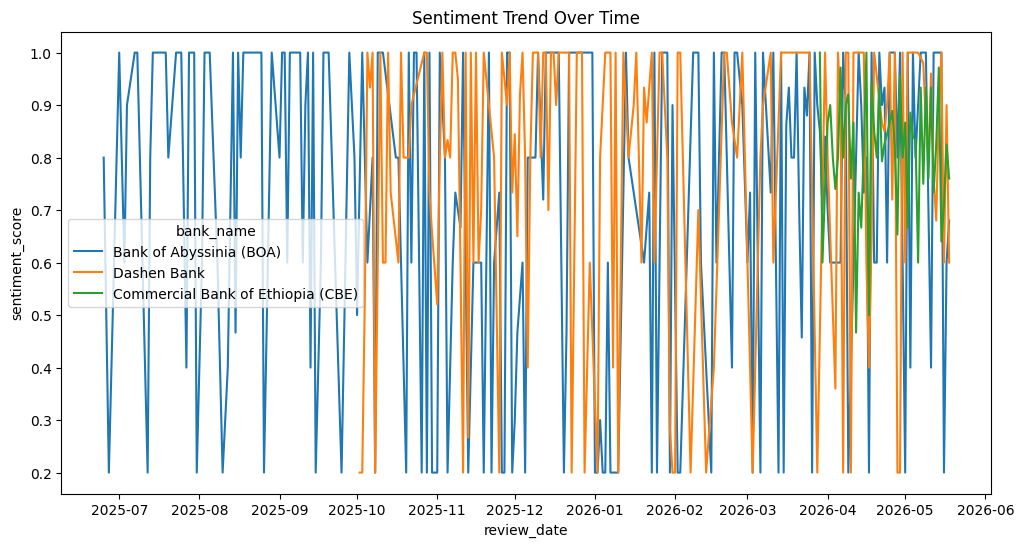

In [50]:
df['sentiment_score'] = df['rating'] / 5

df_time = df.dropna(subset=['review_date'])

trend = df_time.groupby(['review_date', 'bank_name'])['sentiment_score'].mean().reset_index()

plt.figure(figsize=(12,6))

sns.lineplot(data=trend, x='review_date', y='sentiment_score', hue='bank_name')

plt.title("Sentiment Trend Over Time")
plt.show()